In [5]:
pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cache

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('data/raw/reviews.csv')
print(f"Total reviews: {len(df)}")
df.head()

Total reviews: 1000


,id,review,rating,date,bank,source
0,b973c2a8-613a-48c3-977f-8a04574a6d45,cde,2.0,2026-05-19,Commercial Bank of Ethiopia,Google Play
1,e1eaace1-35b5-45d3-99b7-89329b061be8,"fast, easy, and save time.",5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play
2,7e7b2bcf-132d-4469-971b-ebbc396e69bc,jamal Abarhim,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play
3,02f1b774-a513-4acb-90f7-c3a187b2eaa7,it was good!!!,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play
4,d945df55-db37-4f77-be9c-d2d290dc65bf,CBE our pride,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play


In [8]:
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

def get_sentiment_score(rating):
    return (rating - 3) / 2

df['sentiment_label'] = df['rating'].apply(get_sentiment)
df['sentiment_score'] = df['rating'].apply(get_sentiment_score)
print("Sentiment added!")
df.head()

Sentiment added!


,id,review,rating,date,bank,source,sentiment_label,sentiment_score
0,b973c2a8-613a-48c3-977f-8a04574a6d45,cde,2.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,negative,-0.5
1,e1eaace1-35b5-45d3-99b7-89329b061be8,"fast, easy, and save time.",5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive,1.0
2,7e7b2bcf-132d-4469-971b-ebbc396e69bc,jamal Abarhim,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive,1.0
3,02f1b774-a513-4acb-90f7-c3a187b2eaa7,it was good!!!,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive,1.0
4,d945df55-db37-4f77-be9c-d2d290dc65bf,CBE our pride,5.0,2026-05-19,Commercial Bank of Ethiopia,Google Play,positive,1.0


In [9]:
print("Sentiment Distribution:")
print(df['sentiment_label'].value_counts())
print("\nBy Bank:")
print(df.groupby(['bank','sentiment_label']).size().unstack(fill_value=0))

Sentiment Distribution:
sentiment_label
positive    700
negative    250
neutral      50
Name: count, dtype: int64

By Bank:
sentiment_label              negative  neutral  positive
bank                                                    
Bank of Abyssinia                 163       19       318
Commercial Bank of Ethiopia        87       31       382


<Figure size 1000x600 with 0 Axes>

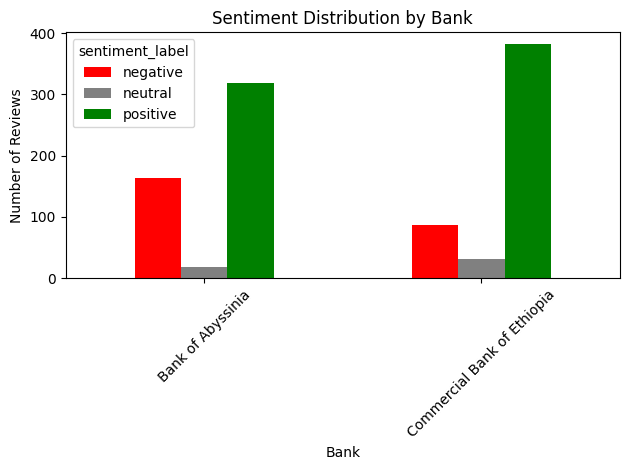

In [10]:
plt.figure(figsize=(10,6))
df.groupby(['bank','sentiment_label']).size().unstack(fill_value=0).plot(
    kind='bar',
    color=['red','gray','green']
)
plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
from collections import Counter
import re

def get_keywords(text):
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    words = text.split()
    # Remove common words
    stopwords = ['the','a','an','is','it','in','on','and','or','to','i','my','me','this','that','was','for','of','with','have','has','be','are','not','but']
    return [w for w in words if w not in stopwords and len(w) > 2]

# Get keywords for each bank
for bank in df['bank'].unique():
    bank_reviews = df[df['bank'] == bank]['review']
    all_words = []
    for review in bank_reviews:
        all_words.extend(get_keywords(review))
    top_words = Counter(all_words).most_common(10)
    print(f"\n{bank} top keywords:")
    for word, count in top_words:
        print(f"  {word}: {count}")


Commercial Bank of Ethiopia top keywords:
  good: 121
  app: 110
  its: 39
  nice: 38
  very: 35
  best: 35
  cbe: 29
  bank: 23
  you: 21
  working: 20

Bank of Abyssinia top keywords:
  app: 174
  good: 99
  very: 50
  best: 43
  bank: 41
  its: 39
  boa: 34
  mobile: 29
  when: 29
  banking: 27


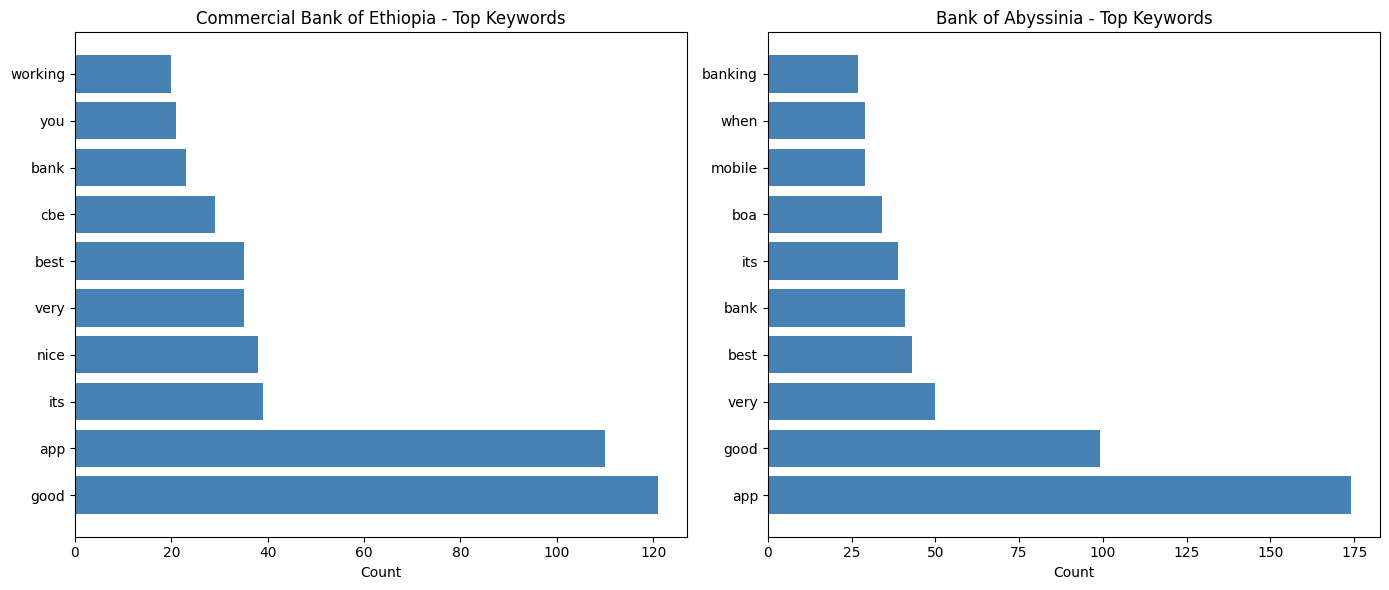

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, bank in enumerate(df['bank'].unique()):
    bank_reviews = df[df['bank'] == bank]['review']
    all_words = []
    for review in bank_reviews:
        all_words.extend(get_keywords(review))
    top_words = Counter(all_words).most_common(10)
    words = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]
    
    axes[idx].barh(words, counts, color='steelblue')
    axes[idx].set_title(f'{bank} - Top Keywords')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [13]:
themes = {
    'Performance': ['slow','crash','loading','fast','speed','hang'],
    'UI & Design': ['interface','design','ui','easy','simple','nice'],
    'Customer Support': ['support','help','service','response','customer'],
    'Features': ['feature','transfer','payment','login','fingerprint'],
    'Reliability': ['error','problem','issue','bug','fix','working']
}

def identify_theme(review):
    review = str(review).lower()
    for theme, keywords in themes.items():
        if any(word in review for word in keywords):
            return theme
    return 'General'

df['identified_theme'] = df['review'].apply(identify_theme)
print(df.groupby(['bank','identified_theme']).size().unstack(fill_value=0))

identified_theme             Customer Support  Features  General  Performance  \
bank                                                                            
Bank of Abyssinia                          13         8      358           49   
Commercial Bank of Ethiopia                25        19      351           28   

identified_theme             Reliability  UI & Design  
bank                                                   
Bank of Abyssinia                     38           34  
Commercial Bank of Ethiopia           23           54  
